# Code Assignment 16 — K-Means Clustering (Mall Customers, 2–3 Features Only)

**Format:** Instructor Guidance → Your Task (step-by-step) → We Share (reflection)

**Goal:** Build a **K-Means** clustering model using **only 2–3 simple numeric features** with **minimal cleaning**, pick **K** via **Elbow + Silhouette** on the **train split**, and sanity-check **generalization** on the **test split**. Then profile clusters in plain business terms.

**Dataset (simple, non-transportation):** *Mall Customers* (public, widely used teaching dataset)  

> We will only use **2–3 numeric columns**: e.g., `Age`, `Annual Income (k$)`, `Spending Score (1-100)`.  



## Instructor Guidance (Pseudocode + Docs)

**Docs:**  
- `train_test_split`: https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html  
- `StandardScaler`: https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html  
- `KMeans`: https://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html  
- `silhouette_score`: https://scikit-learn.org/stable/modules/generated/sklearn.metrics.silhouette_score.html

### Pseudocode Plan (Minimal)
1) **Load CSV** → preview columns/shape.  
2) **Pick 2–3 numeric features** (e.g., Age, Income, SpendingScore).  
3) **Drop NA only** on those columns.  
4) **Split**: `train_test_split(X, test_size=0.2, random_state=42)`.  
5) **Scale**: `StandardScaler` — **fit on TRAIN**, transform TRAIN and TEST.  
6) **Choose K** on TRAIN: loop K=2..8 → plot **Elbow (inertia)** and **Silhouette**.  
7) **Fit final KMeans** on TRAIN with your chosen K; predict TRAIN & TEST labels.  
8) **Sanity check**: report **Silhouette (TRAIN vs TEST)**.  
9) **Profile clusters**: per-cluster means of your 2–3 features (no extra cleaning).  
10) **Reflection**: justify K, describe segments, suggest one action per segment.


## Your Task — Step-by-Step
Work in pairs. Keep code minimal. Use only 2–3 features.

### 1) Imports & Settings

In [4]:
import pandas as pd 
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

### 2) Load the Mall Customers CSV & Preview

In [2]:
df = pd.read_csv('/Users/Marcy_Student/Desktop/marcy/DA2025_Lectures_Kevin/Mod6/data/Mall_Customers copy.csv')

df

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
...,...,...,...,...,...
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18


### 3) Select **2–3 Numeric Features** (no heavy cleaning)
Choose from:
- `Age`
- `Annual Income (k$)`
- `Spending Score (1-100)`

> Keep it simple: e.g., use **Age + Spending Score** (2D) or **Age + Income + Spending Score** (3D).


In [ ]:
# keeping only numeric 
features = ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']

X = df[features].dropna().copy()
X.head()

,Age,Annual Income (k$),Spending Score (1-100)
0,19,15,39
1,21,15,81
2,20,16,6
3,23,16,77
4,31,17,40


### 4) Train–Test Split (for model generalization sanity check)

In [7]:
X_train, X_test = train_test_split(X, test_size=0.20, random_state=42)
print("TRAIN shape:", X_train.shape, "TEST shape:", X_test.shape)

TRAIN shape: (160, 3) TEST shape: (40, 3)


### 5) Scale (fit on TRAIN only), then Explore K on TRAIN (Elbow + Silhouette)

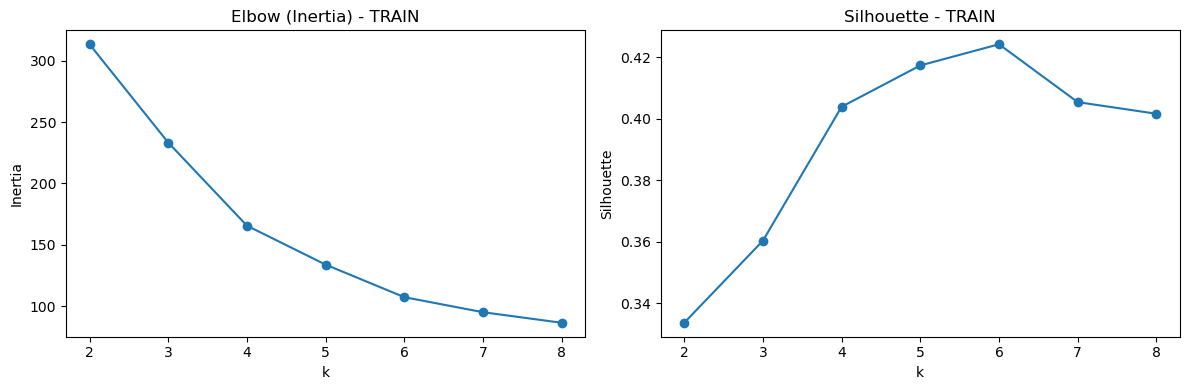

Inertias: [(2, np.float64(313.44)), (3, np.float64(233.32)), (4, np.float64(165.58)), (5, np.float64(133.83)), (6, np.float64(107.3)), (7, np.float64(95.04)), (8, np.float64(86.41))]
Silhouettes: [(2, np.float64(0.334)), (3, np.float64(0.36)), (4, np.float64(0.404)), (5, np.float64(0.417)), (6, np.float64(0.424)), (7, np.float64(0.405)), (8, np.float64(0.402))]


In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

ks = list(range(2, 9))
inertias = []
silhouettes = []

for k in ks:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_train_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_train_scaled, labels))

# Plot elbow + silhouette
fig, axes = plt.subplots(1, 2, figsize=(12,4))
axes[0].plot(ks, inertias, '-o')
axes[0].set_xlabel('k'); axes[0].set_ylabel('Inertia'); axes[0].set_title('Elbow (Inertia) - TRAIN')
axes[1].plot(ks, silhouettes, '-o')
axes[1].set_xlabel('k'); axes[1].set_ylabel('Silhouette'); axes[1].set_title('Silhouette - TRAIN')
plt.tight_layout()
plt.show()


### 6) Choose **K** (justify), Fit Final Model on TRAIN, Check Stability on TEST
- Report **Silhouette TRAIN vs TEST** (higher is better; similar values suggest stability).

In [10]:
best_k = ks[int(np.argmax(silhouettes))]
print("Chosen K (silhouette peak) =", best_k)

kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=20)
train_labels = kmeans.fit_predict(X_train_scaled)
test_labels = kmeans.predict(X_test_scaled)

sil_train = silhouette_score(X_train_scaled, train_labels)
sil_test = silhouette_score(X_test_scaled, test_labels)

print(f"Silhouette TRAIN = {sil_train:.3f}")
print(f"Silhouette TEST  = {sil_test:.3f}")

Chosen K (silhouette peak) = 6
Silhouette TRAIN = 0.424
Silhouette TEST  = 0.386


### 7) Profile Clusters (Business-Readable)
- Use the **original (unscaled)** features for interpretation.
- Show per-cluster means of your **2–3 features**.

TRAIN cluster profile (unscaled):


,count,Age,Annual Income (k$),Spending Score (1-100)
cluster,,,,
0,24,39.46,90.29,17.00
1,27,28.00,56.30,49.41
2,20,24.95,25.15,78.45
3,34,32.94,87.82,82.97
4,37,56.62,55.22,49.00
5,18,44.94,26.56,18.83


TEST cluster profile (unscaled):


,count,Age,Annual Income (k$),Spending Score (1-100)
cluster,,,,
0,9,44.11,85.67,16.78
1,11,24.55,57.55,48.45
2,3,25.33,26.00,72.00
3,5,31.00,77.80,76.40
4,9,55.44,52.22,45.11
5,3,49.00,24.67,22.67


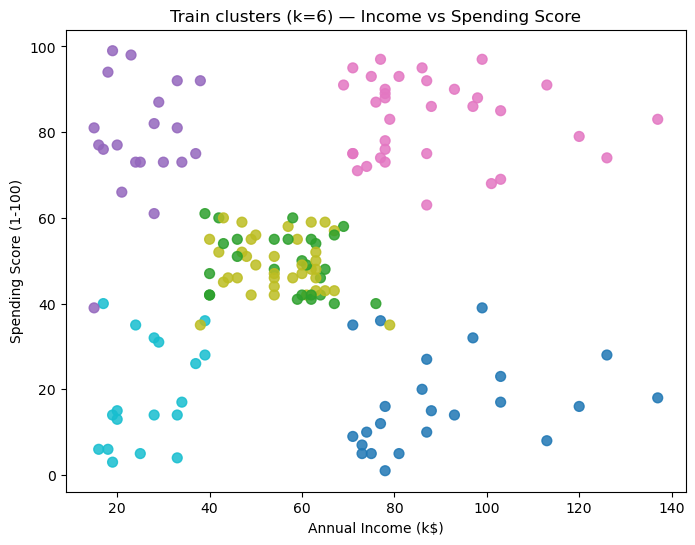

In [11]:
X_train_profile = X_train.copy().reset_index(drop=True)
X_train_profile['cluster'] = train_labels
train_profile = X_train_profile.groupby('cluster')[features].mean().round(2)
train_profile['count'] = X_train_profile['cluster'].value_counts().sort_index().values
train_profile = train_profile[['count'] + features]
print("TRAIN cluster profile (unscaled):")
display(train_profile)

X_test_profile = X_test.copy().reset_index(drop=True)
X_test_profile['cluster'] = test_labels
test_profile = X_test_profile.groupby('cluster')[features].mean().round(2)
test_profile['count'] = X_test_profile['cluster'].value_counts().sort_index().values
test_profile = test_profile[['count'] + features]
print("TEST cluster profile (unscaled):")
display(test_profile)

# quick scatter (Income vs Spending Score) colored by cluster (TRAIN)
plt.figure(figsize=(8,6))
plt.scatter(X_train['Annual Income (k$)'], X_train['Spending Score (1-100)'], c=train_labels, cmap='tab10', s=50, alpha=0.85)
plt.xlabel('Annual Income (k$)'); plt.ylabel('Spending Score (1-100)')
plt.title(f'Train clusters (k={best_k}) — Income vs Spending Score')
plt.show()


## We Share — Reflection (2 short paragraphs)

1) **K choice & stability:** What **K** did you choose and why (Elbow bend, Silhouette peak/plateau, simplicity)? Report **Silhouette (TRAIN vs TEST)** — did structure persist, or did it collapse on test? 

- I selected K = 6 because the Elbow curve showed diminishing improvement after around 5–6 clusters, and the Silhouette score reached its peak at K=6, meaning the clusters were most well-separated at that point. The model's Silhouette score was 0.424 on the training set and 0.386 on the test set, which are close in value. This indicates that the cluster structure holds up reasonably well and does not collapse when applied to unseen data. While smaller K values could have simplified interpretation, K=6 provides a significant difference between customer behavior.

2) **Segments & actions:** Give short names to your segments (e.g., “Young High-Spend,” “Mid-Age Value-Seeker,” “Older Low-Spend”) and suggest **one actionable idea** for each (targeted offers, product mix, messaging).

| **Segment Name**                      | **Who They Are**                                                  | **Recommended Action**                                                                   |
| ------------------------------------- | ----------------------------------------------------------------- | ---------------------------------------------------------------------------------------- |
| **Young High-Spenders**               | Younger (late teens to 30s) with high spending behavior           | Offer **exclusive drops, loyalty rewards, and influencer-style promotions**              |
| **Mid-Income Steady Buyers**          | Middle-aged with moderate income and consistent spending patterns | Provide **personalized recommendations and membership perks** to encourage repeat visits |
| **Older Low-Spenders**                | Older adults with consistently low purchase activity              | Send **discount-focused messaging and simplified offers**                                |
| **High-Income Low-Engagement**        | Higher-income adults who spend surprisingly little                | Use **VIP invitations, curated product bundles, or concierge-style outreach**            |
| **Budget-Conscious Younger Shoppers** | Younger but lower income with limited spending                    | Promote **student deals, bundles,**                                                      |
